In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
from src import utils 

import importlib
import src.fatemarkers
import src.meshharm

importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [3]:
path = 'Data/20250714/fractal_output/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum'],
    'day2': ['0_fused_zillum'],
    'day2p5': ['0_fused_zillum'],
    'day3': ['0_fused_zillum'],
    'day3p5': ['0_fused_zillum'],
    'day4': ['0_fused_zillum'],
    'day4p5': ['0_fused_zillum'],
    'day4p5-more': ['0_fused_zillum'],
}
times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [4]:
def load(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    hks = [] 
    spectrums = [] 
    for t in ts:
        x = np.einsum('i, ji->j', np.exp(-m.eigvals*t), m.eigvecs**2)
        hks.append(x) 
    hks = np.array(hks).T 
    coeffs_hks = m.eigvecs.T @ (m.mass_matrix @ hks)
    spectrums = m.compute_spectrum(coeffs_hks)
    
    return hks, np.sqrt(np.array(spectrums)), frac_diff

def convert_to_bof(hks, scaler, kmeans, sigma):
    rescaled = scaler.transform(hks) 
    dist = kmeans.transform(rescaled)
    encoding = np.exp(-dist**2/(2*sigma**2))
    return encoding


In [5]:
spectrums = [] 
hkss = [] 
times = [] 
fracs = [] 
ids = [] 

ts = np.exp(2*np.linspace(0, np.log(10), 100))



for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(file_path + 'good_labels.npy').astype('int')
        print(file_path) 
        for label in tqdm(labels[::10]):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                hks, coor_spectrum, frac = load(save_path, ts=ts)
                hkss.append(hks)
                spectrums.append(coor_spectrum)
                times.append(timepoint[3:6])
                fracs.append(frac)
                ids.append(f"{timepoint}_{well_name}_{label}") 

Data/20250714/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum/


100%|██████████| 12/12 [00:04<00:00,  2.61it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/02/0_fused_zillum/


100%|██████████| 6/6 [00:02<00:00,  2.63it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/03/0_fused_zillum/


...

100%|██████████| 10/10 [00:02<00:00,  4.83it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/05/0_fused_zillum/


100%|██████████| 11/11 [00:02<00:00,  4.84it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum/


100%|██████████| 14/14 [00:02<00:00,  4.80it/s]


In [6]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

# Convert boolean mask to indices array
recon_indices = np.where(recon_mask)[0]

filtered_times = np.array(times)[recon_mask]
filtered_spectrums = np.array(spectrums)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]

In [9]:

# Apply indices to filter hkss list
filtered_hks = [hkss[i] for i in recon_indices]
collected_hks = np.concatenate(filtered_hks)

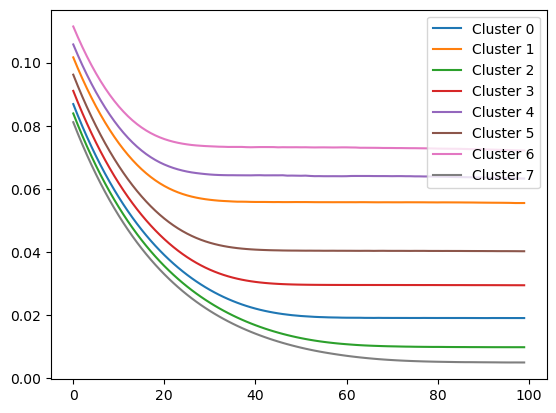

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
rescaled_hks = scaler.fit_transform(collected_hks)

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(rescaled_hks)
vocab = kmeans.cluster_centers_ 
vocab_og = scaler.inverse_transform(vocab)


for i, v in enumerate(vocab_og): 
    plt.plot(v, label=f'Cluster {i}')
plt.legend() 
plt.show() 



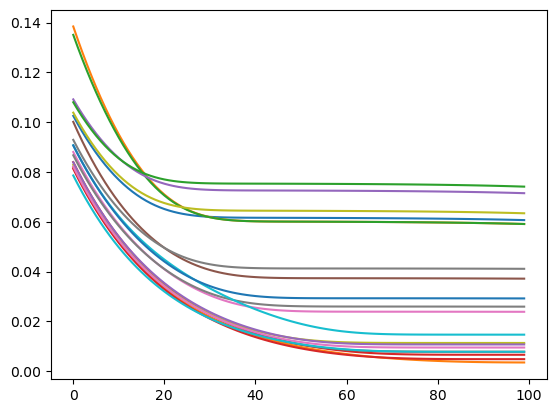

In [263]:

import random
random_indices = [random.randint(0, len(collected_hks)-1) for _ in range(20)]

for i in random_indices: 
    plt.plot(collected_hks[i], label=f'Point {i}')
plt.show() 


In [ ]:
cluster_id = kmeans.predict(rescaled_hks)

dist = kmeans.transform(rescaled_hks)
sigma = np.mean(dist[np.arange(dist.shape[0]), cluster_id])

In [266]:
np.savez('sim/vocab.npz', vocab=vocab, scalar=scaler, ts=ts, sigma=sigma)

In [7]:
res = np.load('sim/vocab.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scalar'].item() 
sigma = res['sigma']
ts = res['ts']

In [11]:
bof_spectrums = [] 
for hks, id in tqdm(zip(filtered_hks, filtered_ids)):
     rescaled = scaler.transform(hks) 
     dist = np.linalg.norm(rescaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
     encoding = np.exp(-dist**2/(2*sigma**2))
     timepoint, well_name, label = id.split('_')
     zarr_name = zarr_names[timepoint]
     round_name = rounds[timepoint][0]
     file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
     m = FateMarkers()
     m.load_results(file_path) 
     coeffs_hks = m.eigvecs.T @ (m.mass_matrix @ encoding)
     s = m.compute_spectrum(coeffs_hks)
     bof_spectrums.append(np.sqrt(s)/m.mass_matrix.diagonal().sum()) 


341it [00:30, 11.34it/s]


(341, 15, 8)


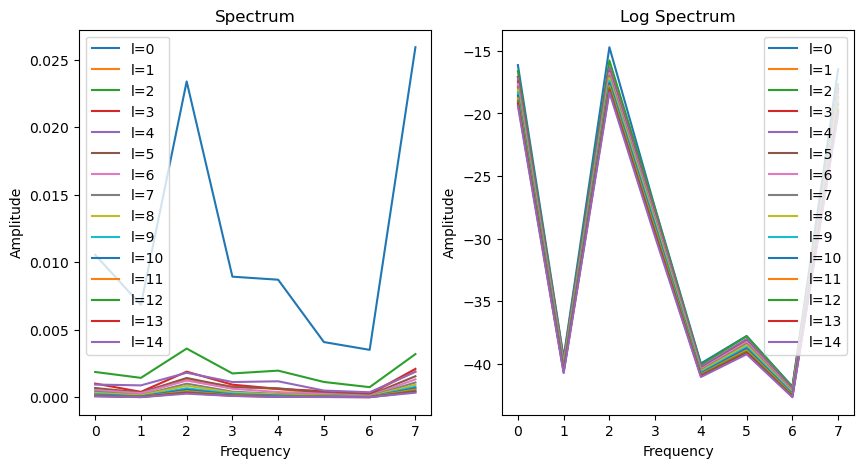

In [12]:
bof_spectrums = np.array(bof_spectrums)
bof_scaled = np.empty_like(bof_spectrums)
print(bof_spectrums.shape)

from sklearn.preprocessing import Normalizer 

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i in range(bof_spectrums.shape[1]):
    axes[0].plot(np.mean(bof_spectrums[:, i, :], axis=0), label=f'l={i}')
    bof_scaled[:, i, :] = np.log(bof_spectrums[:, i, :]+1e-20)

    axes[1].plot(np.mean(bof_scaled[:, i, :], axis=0), label=f'l={i}')

axes[0].legend()
axes[0].set_title("Spectrum")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Amplitude")

axes[1].legend()
axes[1].set_title("Log Spectrum")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Amplitude")

plt.show()

In [42]:
# Reshape the bag-of-features spectrums for feature selection
bof_spectrums_reshaped = bof_scaled.reshape(bof_spectrums.shape[0], -1)

# bof_spectrums_scaled = StandardScaler().fit_transform(bof_spectrums_reshaped)
bof_spectrums_scaled = np.copy(bof_spectrums_reshaped) 

In [47]:
n_clusters = 5
kmeans_spectrums = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_spectrums.fit(bof_spectrums_scaled)

dist = kmeans_spectrums.transform(bof_spectrums_scaled)
cluster_id = np.argmin(dist, axis=1)


from sklearn.manifold import MDS, TSNE 
mds = TSNE(n_components=2, random_state=42, perplexity=30)

to_fit = np.concatenate((bof_spectrums_scaled, kmeans_spectrums.cluster_centers_), axis=0)
mds.fit(to_fit)
reduced_dim_rep = mds.fit_transform(to_fit)

spectrum_pcs = reduced_dim_rep[:bof_spectrums_scaled.shape[0], :]
cluster_pcs = reduced_dim_rep[bof_spectrums_scaled.shape[0]:, :]

# import umap
# reducer = umap.UMAP(n_components=2, random_state=42)
# spectrum_pcs = reducer.fit_transform(bof_spectrums_scaled) 
# cluster_pcs = reducer.transform(kmeans.cluster_centers_)



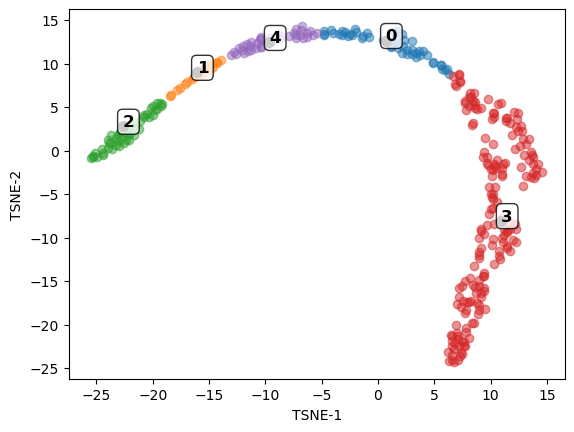

In [51]:


for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(spectrum_pcs[mask, 0], spectrum_pcs[mask, 1], 'o', alpha=0.5)

plt.plot(cluster_pcs[:, 0], cluster_pcs[:, 1], 'o', markersize=7, color='black')

for i in range(len(cluster_pcs)): 
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

['1p5' '2' '2p5' '3' '3p5' '4' '4p5']


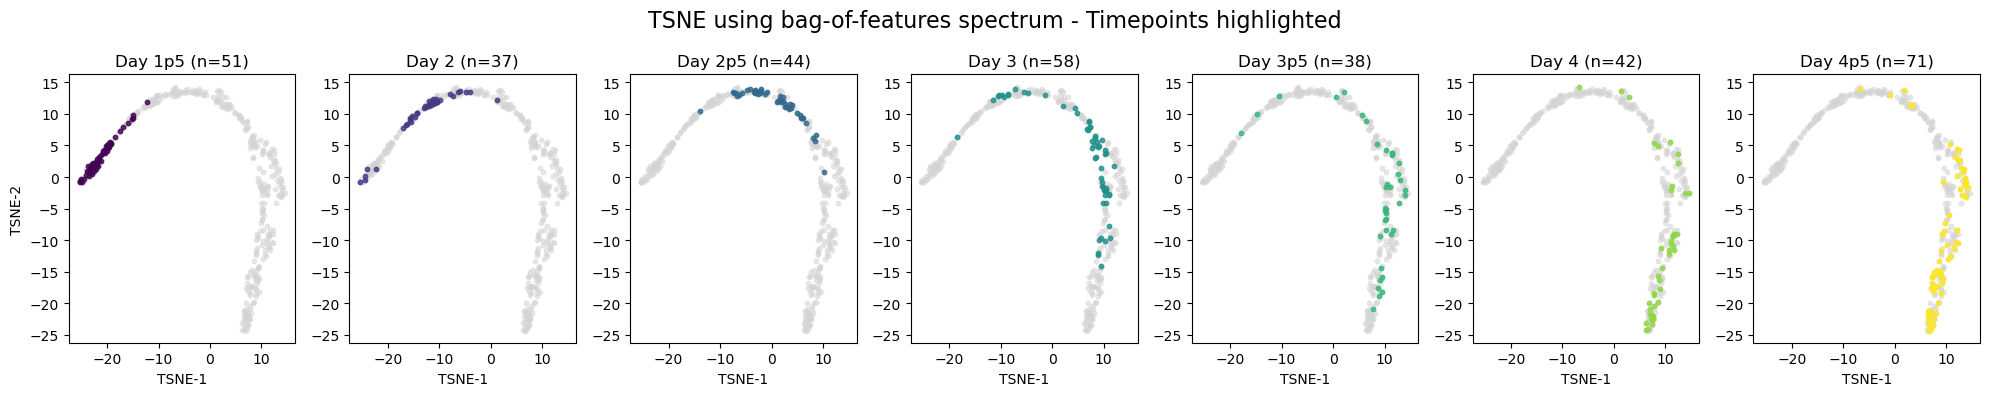

In [48]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(filtered_times)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 7, figsize=(20, 4))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.5, s=10)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (filtered_times == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=10, label=f'Day {time}')
    
    ax.set_xlabel('TSNE-1')
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')

axes[0].set_ylabel('TSNE-2')
plt.suptitle('TSNE using bag-of-features spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
dist = kmeans_spectrums.transform(bof_spectrums_scaled)

# Find the closest point to each cluster center
cluster_center_ids = filtered_ids[np.argmin(dist, axis=0)[[2, 1, 4, 0, 3]]]

print(cluster_center_ids) 

['day1p5_A01_189' 'day2_A05_35' 'day2_A03_91' 'day3p5_A03_75' 'day3_B03_1']


In [53]:
from meshplot import plot

for i, id in enumerate(cluster_center_ids): 
    timepoint, well_name, label = id.split('_')
    zarr_name = zarr_names[timepoint]
    round_name = rounds[timepoint][0]
    file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
    m = FateMarkers()
    m.load_results(file_path) 

    coeffs_hks = m.compute_hks_for_new_times(new_ts=[4])
    hks = m.reconstruct_from_coeffs(coeffs_hks[:])
    
    # Create the meshplot visualization
    print(np.min(hks[:, -1]), np.max(hks[:, -1]))
    plot(m.v, m.f, c=hks[:, -1])

0.06185616 0.062276933


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000979…

0.04242908 0.04397282


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.064193…

0.03253024 0.034747183


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0048953…

0.026018273 0.028932085


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.048001…

0.020667981 0.024912773


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0500390…